<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `DecodingExampleWithHist.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: The notebook now mirrors the MATLAB history-aware decoding workflow closely; exact stochastic trajectories and figure styling still vary slightly under Python execution.


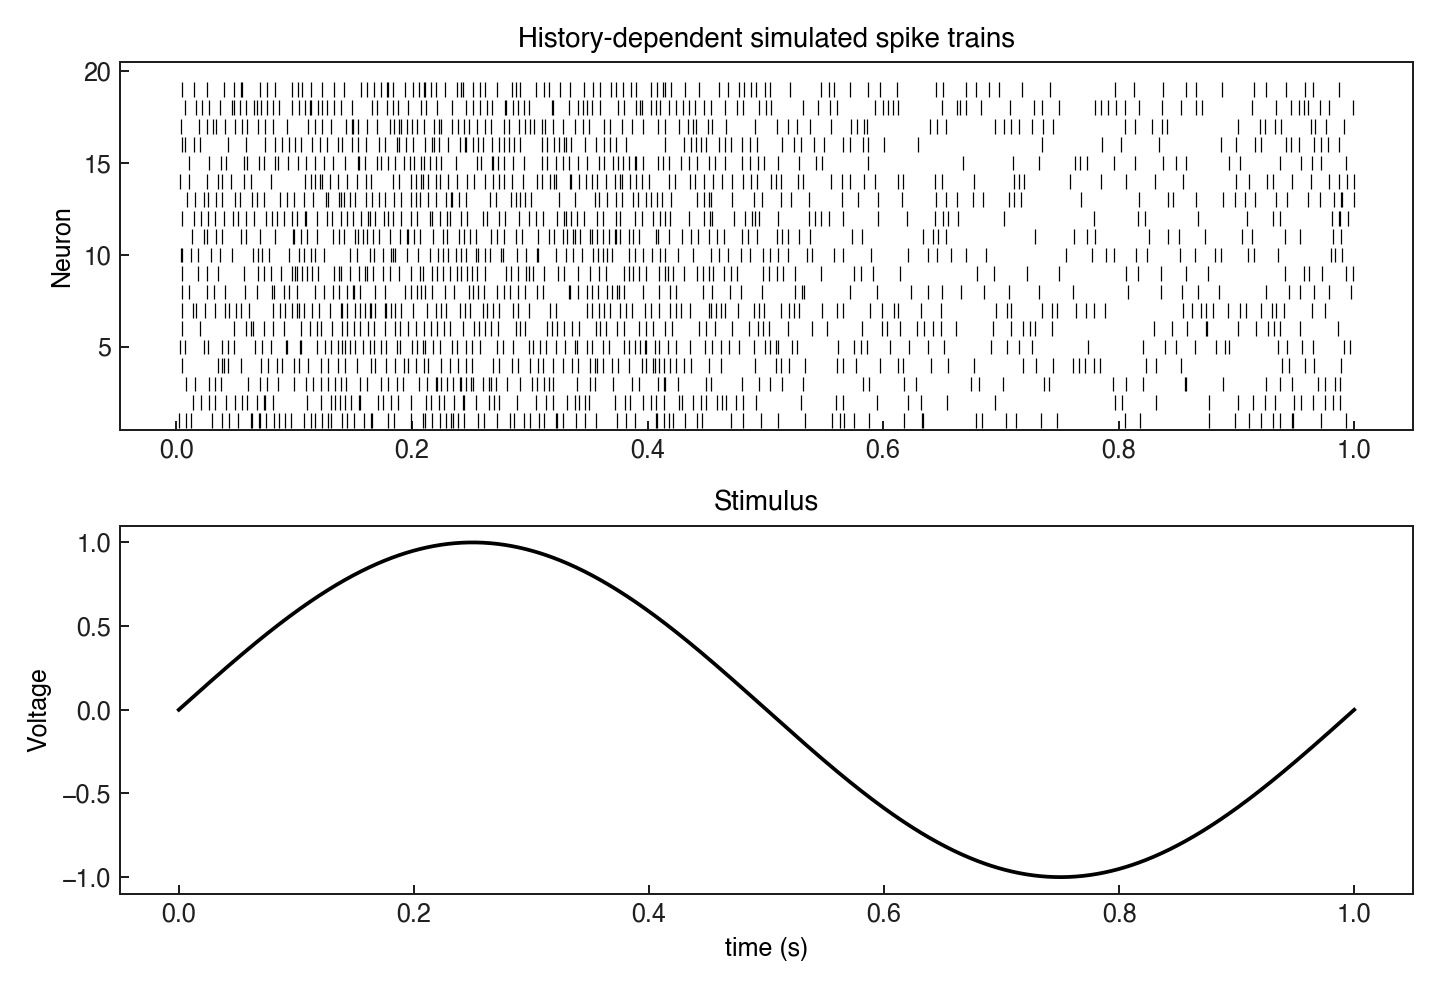

In [ ]:
# nSTAT-python notebook example: DecodingExampleWithHist
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import CIF, DecodingAlgorithms, History, Covariate, nspikeTrain, nstColl
from nstat.notebook_figures import FigureTracker, matlab_raster

np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="DecodingExampleWithHist", output_root=OUTPUT_ROOT, expected_count=2)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _plot_raster(ax, spike_coll):
    for row in range(spike_coll.numSpikeTrains):
        train = spike_coll.getNST(row)
        spikes = np.asarray(train.getSpikeTimes(), dtype=float).reshape(-1)
        matlab_raster(ax, spikes, row=row, linewidth=0.5)
    ax.set_ylabel("Neuron")
    ax.set_ylim(0.5, spike_coll.numSpikeTrains + 0.5)


def _plot_decoded_ci(ax, time, decoded, cov, stim, title):
    center = np.asarray(decoded, dtype=float).reshape(-1)
    spread = np.asarray(cov, dtype=float).reshape(-1)
    z_val = 3.0
    lower = center - z_val * spread
    upper = center + z_val * spread
    ax.plot(time[: center.size], center, "b", linewidth=1.5, label="x_{k|k}(t)")
    ax.plot(time[: center.size], lower, "g", linewidth=1.0, label="x_{k|k}(t)-3σ")
    ax.plot(time[: center.size], upper, "r", linewidth=1.0, label="x_{k|k}(t)+3σ")
    ax.plot(time[: center.size], np.asarray(stim).reshape(-1)[: center.size], "k", linewidth=1.5, label="x(t)")
    ax.set_title(title)
    ax.set_xlabel("time (s)")
    ax.legend(loc="upper right", frameon=False, fontsize=8)


def _simulate_history_spike_train(time, stim_data, baseline, hist_coeffs, window_times):
    spikes = []
    for idx in range(1, len(time)):
        t = time[idx]
        spike_arr = np.asarray(spikes, dtype=float)
        history_counts = []
        for w_start, w_stop in zip(window_times[:-1], window_times[1:]):
            if spike_arr.size:
                history_counts.append(np.sum((spike_arr >= t - w_stop) & (spike_arr < t - w_start)))
            else:
                history_counts.append(0.0)
        eta = baseline + stim_data[idx] + float(np.dot(hist_coeffs, history_counts))
        p = np.exp(np.clip(eta, -20.0, 20.0))
        p = p / (1.0 + p)
        if np.random.rand() < p:
            spikes.append(t)
    return np.asarray(spikes, dtype=float)


# SECTION 0: 1-D Stimulus Decode with History Effect
# We simulate neurons with refractory-history effects and compare point-process decoding with and without the correct history terms.


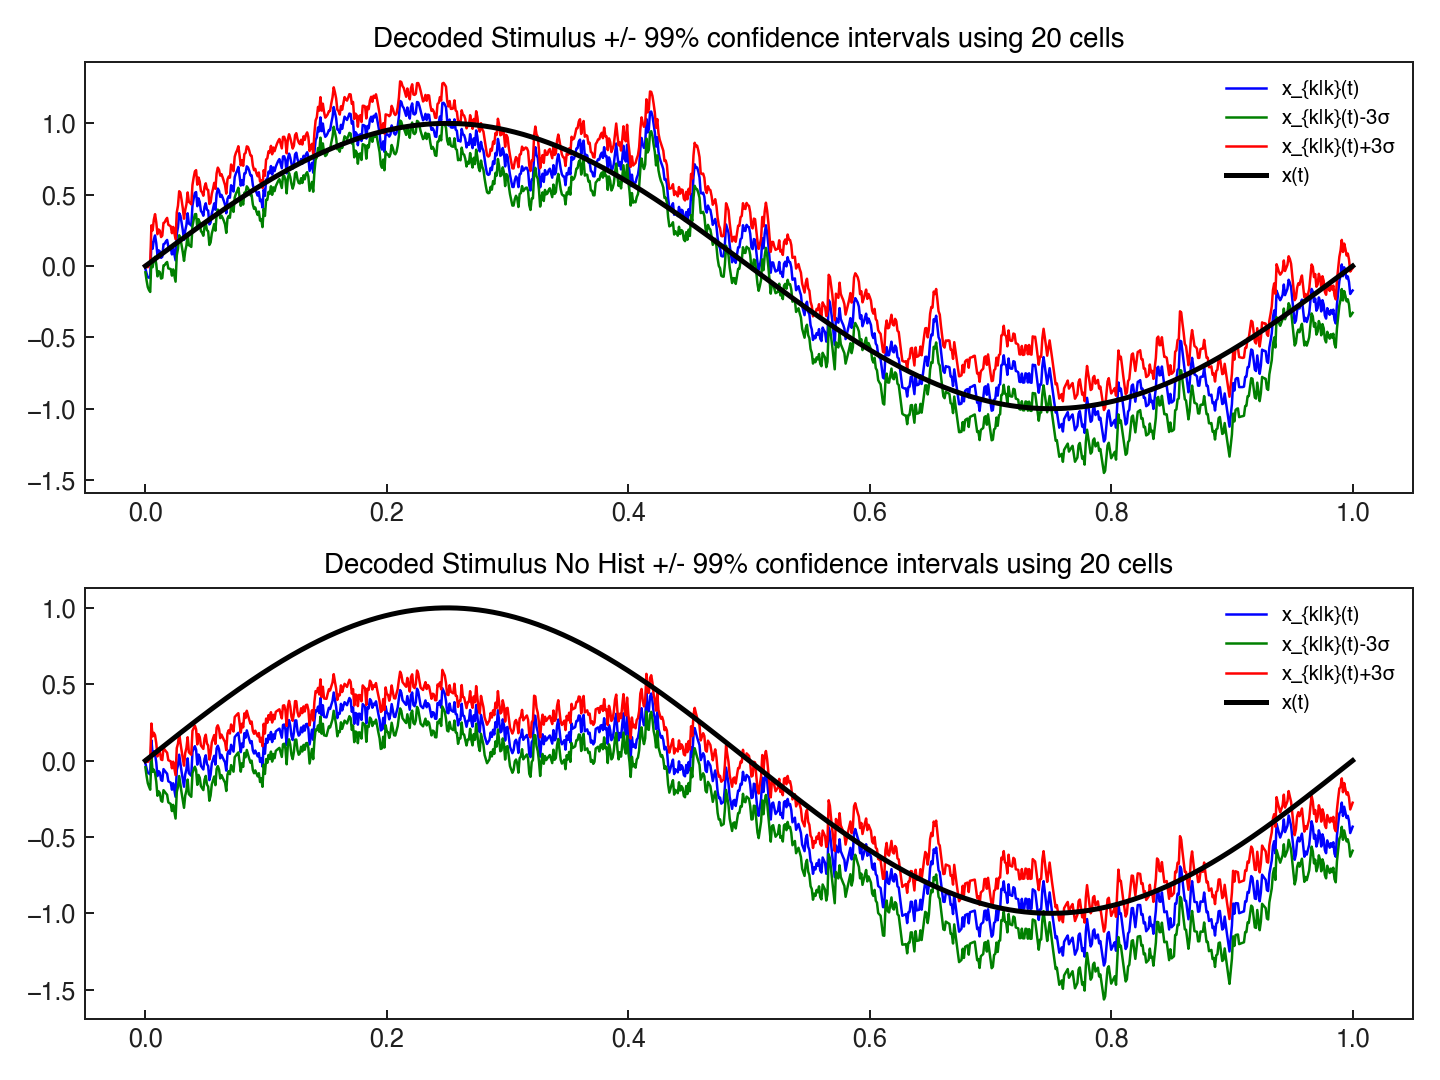

In [ ]:
# SECTION 1: 1-D Stimulus Decode with History Effect
plt.close("all")
delta = 0.001
Tmax = 1.0
time = np.arange(0.0, Tmax + delta, delta)
f = 1.0
b1 = 1.0
b0 = -2.0
# Mirror MATLAB: stimData = b1*sin(2*pi*f*time)
_sin_arg = 2.0 * np.pi * f * time
_sin_vec = np.sin(_sin_arg)
stimData = b1 * _sin_vec
e = np.zeros(len(time))  # No Ensemble input
mu = b0  # baseline firing rate
Ts = delta

histCoeffs = np.array([-2.0, -2.0, -4.0])
windowTimes = np.array([0.0, 0.001, 0.002, 0.003])
histObj = History(windowTimes)
filts = histObj.toFilter(Ts)  # Convert to transfer function matrix (MATLAB parity)
stim = Covariate(time, stimData, "Stimulus", "time", "s", "Voltage", ["sin"])
ens = Covariate(time, e, "Ensemble", "time", "s", "Spikes", ["n1"])  # No ensemble effect

numRealizations = 20  # Number of sample paths to generate
trains = []
for idx in range(numRealizations):
    spikes = _simulate_history_spike_train(time, stimData, b0, histCoeffs, windowTimes)
    trains.append(nspikeTrain(spikes, str(idx + 1), 1.0 / delta, 0.0, Tmax, makePlots=-1))
sC = nstColl(trains)

# Mirror MATLAB: figure; subplot(2,1,1) sC.plot ; subplot(2,1,2) stim.plot
fig = _prepare_figure("figure", figsize=(8.0, 5.5))
ax1 = plt.subplot(2, 1, 1)
_plot_raster(ax1, sC)
ax1.set_title("History-dependent simulated spike trains")
ax2 = plt.subplot(2, 1, 2)
ax2.plot(time, stim.data[:, 0], color="k", linewidth=1.5)
ax2.set_title("Stimulus")
ax2.set_xlabel("time (s)")
ax2.set_ylabel("Voltage")

# Construct a CIF object for each realization (MATLAB parity)
# correct CIF w/ History
_proto_cif_hist = CIF([b0, b1], ["1", "x"], ["x"], "binomial", histCoeffs, histObj)
# CIF ignoring the history effect
_proto_cif_no_hist = CIF([b0, b1], ["1", "x"], ["x"], "binomial")
lambdaCIF = [_proto_cif_hist for _ in range(numRealizations)]
lambdaCIFNoHist = [_proto_cif_no_hist for _ in range(numRealizations)]

sC.resample(1.0 / delta)
dN = sC.dataToMatrix()
# Make noise according to the dynamic range of the stimulus (MATLAB parity)
_stim_data = stim.data[:, 0]
_stim_diffs = np.diff(_stim_data)
_std_val = np.std(_stim_diffs)
Q = 2.0 * _std_val
Px0 = 0.1
A = 1.0
# Decode with the correct and incorrect CIFs (MATLAB parity)
x_p, W_p, x_u, W_u, *_ = DecodingAlgorithms.PPDecodeFilter(A, Q, Px0, dN.T, lambdaCIF, delta)
x_pNoHist, W_pNoHist, x_uNoHist, W_uNoHist, *_ = DecodingAlgorithms.PPDecodeFilter(
    A,
    Q,
    Px0,
    dN.T,
    lambdaCIFNoHist,
    delta,
)

# Compare the results (MATLAB parity): figure; subplot(2,1,1) ... subplot(2,1,2) ...
fig = _prepare_figure("figure", figsize=(8.0, 6.0))

ax_hist = plt.subplot(2, 1, 1)
zVal = 3
_x_u_arr = np.asarray(x_u, dtype=float)
_x_u_raw = _x_u_arr.reshape(-1)
_W_u_arr = np.asarray(W_u, dtype=float)
ciLower = np.min(_x_u_raw - zVal * _W_u_arr.reshape(-1))
_W_u_sq1 = np.squeeze(_W_u_arr)
ciUpper = np.max(_x_u_raw + zVal * _W_u_arr.reshape(-1))
_W_u_sq2 = np.squeeze(_W_u_arr)
ciLower = np.minimum(_x_u_raw - zVal * _W_u_sq1.reshape(-1), _x_u_raw + zVal * _W_u_sq1.reshape(-1))
ciUpper = np.maximum(_x_u_raw - zVal * _W_u_sq2.reshape(-1), _x_u_raw + zVal * _W_u_sq2.reshape(-1))
hEst = ax_hist.plot(time[: _x_u_raw.size], _x_u_raw, "b", time[: _x_u_raw.size], ciLower, "g", time[: _x_u_raw.size], ciUpper, "r")
hStim = ax_hist.plot(time, _stim_data, "k", linewidth=2)
ax_hist.legend(
    [hEst[0], hEst[1], hEst[2], hStim[0]],
    ["x_{k|k}(t)", f"x_{{k|k}}(t)-{zVal}σ", f"x_{{k|k}}(t)+{zVal}σ", "x(t)"],
    loc="upper right",
    frameon=False,
    fontsize=8,
)
plt.title(f"Decoded Stimulus +/- 99% confidence intervals using {numRealizations} cells")

ax_no = plt.subplot(2, 1, 2)
zVal = 3
_x_no_arr = np.asarray(x_uNoHist, dtype=float)
_x_no_raw = _x_no_arr.reshape(-1)
_W_no_arr = np.asarray(W_uNoHist, dtype=float)
ciLower = np.min(_x_no_raw - zVal * _W_no_arr.reshape(-1))
_W_no_sq1 = np.squeeze(_W_no_arr)
ciUpper = np.max(_x_no_raw + zVal * _W_no_arr.reshape(-1))
_W_no_sq2 = np.squeeze(_W_no_arr)
ciLower = np.minimum(_x_no_raw - zVal * _W_no_sq1.reshape(-1), _x_no_raw + zVal * _W_no_sq1.reshape(-1))
ciUpper = np.maximum(_x_no_raw - zVal * _W_no_sq2.reshape(-1), _x_no_raw + zVal * _W_no_sq2.reshape(-1))
hEst = ax_no.plot(time[: _x_no_raw.size], _x_no_raw, "b", time[: _x_no_raw.size], ciLower, "g", time[: _x_no_raw.size], ciUpper, "r")
hStim = ax_no.plot(time, _stim_data, "k", linewidth=2)
ax_no.legend(
    [hEst[0], hEst[1], hEst[2], hStim[0]],
    ["x_{k|k}(t)", f"x_{{k|k}}(t)-{zVal}σ", f"x_{{k|k}}(t)+{zVal}σ", "x(t)"],
    loc="upper right",
    frameon=False,
    fontsize=8,
)
plt.title(f"Decoded Stimulus No Hist +/- 99% confidence intervals using {numRealizations} cells")

__tracker.finalize()
